In [1]:
"""Array transfer function / array response function plotting.

Implements the classic plane-wave array response function used in Schweitzer
Chapter 9 (array transfer function, Eq. 9.20) and produces plots similar to
Figures 9.22 and 9.23.

Assumptions
-----------
- Station coordinates are given relative to the array reference point in km.
- Horizontal coordinates only are used by default (x east, y north).
- The transfer function is computed for a plane wave over a grid in horizontal
  slowness space (sx, sy) [s/km].
- Power is normalized to the maximum and displayed in dB.

If you need elevation effects, the core formula can be extended with z terms,
but for reproducing the figures in Schweitzer’s chapter, the horizontal model
is usually sufficient.
"""

'Array transfer function / array response function plotting.\n\nImplements the classic plane-wave array response function used in Schweitzer\nChapter 9 (array transfer function, Eq. 9.20) and produces plots similar to\nFigures 9.22 and 9.23.\n\nAssumptions\n-----------\n- Station coordinates are given relative to the array reference point in km.\n- Horizontal coordinates only are used by default (x east, y north).\n- The transfer function is computed for a plane wave over a grid in horizontal\n  slowness space (sx, sy) [s/km].\n- Power is normalized to the maximum and displayed in dB.\n\nIf you need elevation effects, the core formula can be extended with z terms,\nbut for reproducing the figures in Schweitzer’s chapter, the horizontal model\nis usually sufficient.\n'

In [2]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import zipfile
import xml.etree.ElementTree as ET

In [3]:
@dataclass(frozen=True)
class ArrayGeometry:
    """Array geometry in kilometers relative to a reference point."""
    x_km: np.ndarray  # east
    y_km: np.ndarray  # north
    labels: Optional[list[str]] = None

    @property
    def n(self):
        return self.x_km.size

    @classmethod
    def from_xy(cls, xy: Iterable[Tuple[float, float]], labels: Optional[list[str]] = None) -> "ArrayGeometry":
        arr = np.asarray(list(xy), dtype=float)
        if arr.ndim != 2 or arr.shape[1] != 2:
            raise ValueError("xy must be an iterable of (x_km, y_km) pairs")
        if labels is not None and len(labels) != arr.shape[0]:
            raise ValueError("labels length must match number of stations")
        return cls(x_km=arr[:, 0], y_km=arr[:, 1], labels=labels)

In [4]:
def latlon_to_local_xy_km(
    lat: np.ndarray,
    lon: np.ndarray,
    *,
    lat0: Optional[float] = None,
    lon0: Optional[float] = None,
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """Convert latitude/longitude to local east-north coordinates in km.

    This uses a local tangent-plane approximation centered on (lat0, lon0).
    For small and medium aperture arrays, this is typically sufficient.
    """
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    if lat0 is None:
        lat0 = float(np.mean(lat))
    if lon0 is None:
        lon0 = float(np.mean(lon))

    r_earth_km = 6371.0
    lat_rad = np.deg2rad(lat)
    lon_rad = np.deg2rad(lon)
    lat0_rad = np.deg2rad(lat0)
    lon0_rad = np.deg2rad(lon0)

    x_km = r_earth_km * (lon_rad - lon0_rad) * np.cos(lat0_rad)
    y_km = r_earth_km * (lat_rad - lat0_rad)
    return x_km, y_km, lat0, lon0


In [5]:
def geometry_from_latlon_csv(
    csv_path: str | Path,
    *,
    lat_col: str = "lat",
    lon_col: str = "lon",
    name_col: str = "name",
    lat0: Optional[float] = None,
    lon0: Optional[float] = None,
) -> tuple[ArrayGeometry, dict]:
    """Read a CSV with lat/lon and return local x-y geometry plus metadata."""
    df = pd.read_csv(csv_path)
    for col in (lat_col, lon_col):
        if col not in df.columns:
            raise ValueError(f"CSV is missing required column: {col}")

    labels = df[name_col].astype(str).tolist() if name_col in df.columns else None
    x_km, y_km, lat0_used, lon0_used = latlon_to_local_xy_km(
        df[lat_col].to_numpy(),
        df[lon_col].to_numpy(),
        lat0=lat0,
        lon0=lon0,
    )
    geom = ArrayGeometry(x_km=x_km, y_km=y_km, labels=labels)
    meta = {"lat0": lat0_used, "lon0": lon0_used}
    return geom, meta

    @property
    def n(self) -> int:
        return int(self.x_km.size)

    @property
    def aperture_km(self) -> float:
        dx = self.x_km[:, None] - self.x_km[None, :]
        dy = self.y_km[:, None] - self.y_km[None, :]
        return float(np.max(np.hypot(dx, dy)))

In [6]:
def array_transfer_function(
    geom: ArrayGeometry,
    sx: np.ndarray,
    sy: np.ndarray,
    *,
    steer_sx: float = 0.0,
    steer_sy: float = 0.0,
    normalize: bool = True,
) -> np.ndarray:
    """Compute array response / transfer function on a slowness grid.

    Parameters
    ----------
    geom:
        Array geometry.
    sx, sy:
        1D arrays defining the horizontal slowness grid [s/km].
    steer_sx, steer_sy:
        Steering slowness (the assumed propagation vector). For the common
        ARF-style plot this is (0, 0).
    normalize:
        If True, return power normalized to the global maximum.

    Returns
    -------
    power_db:
        2D array of normalized beam power in dB, shape (len(sy), len(sx)).
    """
    X, Y = np.meshgrid(sx, sy)
    d_sx = X - steer_sx
    d_sy = Y - steer_sy

    # Steering vector sum: A(s) = sum_j exp(i * 2π f? )
    # For the pure geometry transfer function in slowness space, the phase is
    # r · (s - s0).  When using units of s/km and km, the exponent is dimensionless
    # for the canonical transfer-function representation used in the chapter.
    phase = (
        geom.x_km[:, None, None] * d_sx[None, :, :]
        + geom.y_km[:, None, None] * d_sy[None, :, :]
    )
    steering_sum = np.exp(1j * 2.0 * np.pi * phase).sum(axis=0)
    power = np.abs(steering_sum) ** 2 / (geom.n ** 2)

    if normalize:
        power = power / np.max(power)

    # avoid log(0)
    power_db = 10.0 * np.log10(np.maximum(power, 1e-12))
    return power_db

In [7]:
def plot_transfer_function(
    geom: ArrayGeometry,
    *,
    sx_lim: float = 0.5,
    sy_lim: Optional[float] = None,
    ngrid: int = 401,
    levels_db: Tuple[float, ...] = (-9, -7, -5, -3, -1),
    cmap: str = "viridis",
    title: Optional[str] = None,
    outpath: Optional[str | Path] = None,
    show_stations: bool = True,
    frequency: Optional[float] = None,
    use_wavenumber: bool = False,
) -> Tuple[plt.Figure, plt.Axes]:
    """Plot the array transfer function.

    The output is similar in spirit to Schweitzer Fig. 9.22/9.23: a 2D dB power
    map with white contour lines at selected levels.
    """
    if sy_lim is None:
        sy_lim = sx_lim

    sx = np.linspace(-sx_lim, sx_lim, ngrid)
    sy = np.linspace(-sy_lim, sy_lim, ngrid)

    power_db = array_transfer_function(geom, sx, sy)

    # Decide plotting coordinates
    if use_wavenumber:
        if frequency is None:
            raise ValueError("frequency must be provided when use_wavenumber=True")
        kx = frequency * sx / 1000
        ky = frequency * sy / 1000
        x_plot, y_plot = kx, ky
    else:
        x_plot, y_plot = sx, sy

    fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
    extent = [x_plot.min(), x_plot.max(), y_plot.min(), y_plot.max()]

    im = ax.imshow(
        power_db,
        origin="lower",
        extent=extent,
        cmap=cmap,
        vmin=-10,
        vmax=0,
        aspect="equal",
        interpolation="bilinear",
    )

    cs = ax.contour(
        x_plot,
        y_plot,
        power_db,
        levels=sorted(levels_db),
        colors="white",
        linewidths=0.8,
        alpha=0.95,
    )
    ax.clabel(cs, fmt=lambda v: f"{v:g} dB", inline=True, fontsize=8)

    if show_stations:
        ax.scatter(geom.x_km, geom.y_km, s=26, c="k", edgecolors="white", linewidths=0.4, zorder=5)
        if geom.labels is not None:
            for x, y, lbl in zip(geom.x_km, geom.y_km, geom.labels):
                ax.text(x, y, str(lbl), fontsize=8, ha="left", va="bottom", color="black")

    if use_wavenumber:
        ax.set_xlabel("k_x [m$^{-1}$]")
        ax.set_ylabel("k_y [m$^{-1}$]")
    else:
        ax.set_xlabel("W-E slowness [s/km]")
        ax.set_ylabel("N-S slowness [s/km]")
    ax.set_title(title or f"Array transfer function (M={geom.n}, aperture={geom.aperture_km:.2f} km)")
    ax.grid(False)
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Relative power [dB]")

    if outpath is not None:
        outpath = Path(outpath)
        fig.savefig(outpath, dpi=200, bbox_inches="tight")

    return fig, ax

In [8]:
def plot_array_geometry(geom, title="Array geometry"):
    fig, ax = plt.subplots(figsize=(6, 6))

    # Scatter stations
    ax.scatter(
        geom.x_km,
        geom.y_km,
        s=50,
        c="black",
        edgecolors="white",
        linewidths=0.5,
        zorder=3,
    )

    # Labels (if present)
    if geom.labels is not None:
        for x, y, label in zip(geom.x_km, geom.y_km, geom.labels):
            ax.text(x, y, label, fontsize=9, ha="left", va="bottom")

    # Axes formatting
    ax.set_xlabel("East [km]")
    ax.set_ylabel("North [km]")
    ax.set_title(title)
    ax.set_aspect("equal")

    # Center crosshair (useful sanity check)
    ax.axhline(0, linewidth=0.5)
    ax.axvline(0, linewidth=0.5)

    # Padding
    margin = 0.1 * max(abs(geom.x_km).max(), abs(geom.y_km).max())
    ax.set_xlim(geom.x_km.min() - margin, geom.x_km.max() + margin)
    ax.set_ylim(geom.y_km.min() - margin, geom.y_km.max() + margin)

    plt.show()

# NYMAR

Using local origin lat0=54.382620, lon0=-0.657397
Station x/y coordinates in km:
  NYM1      x= -0.0084  y=  0.0231
  NYM2      x=  0.0077  y=  0.2284
  NYM3      x=  0.1520  y= -0.1436
  NYM4      x= -0.1921  y= -0.1046
  NYM5      x=  0.4683  y=  0.0783
  NYM6      x=  0.0774  y= -0.5136
  NYM7      x= -0.4371  y= -0.0495
  NYM8      x= -0.0678  y=  0.4816


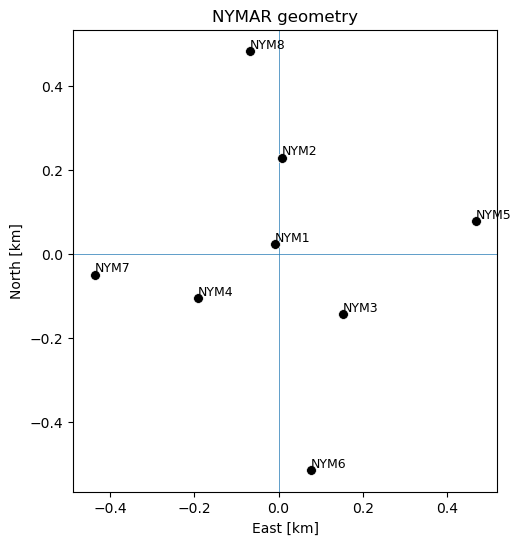

In [9]:
csv_path = "nymar_locs.csv"
geom, meta = geometry_from_latlon_csv(csv_path)
print(f"Using local origin lat0={meta['lat0']:.6f}, lon0={meta['lon0']:.6f}")
print("Station x/y coordinates in km:")
for name, x, y in zip(geom.labels or [], geom.x_km, geom.y_km):
    print(f"  {name:8s}  x={x:8.4f}  y={y:8.4f}")

plot_array_geometry(geom, title="NYMAR geometry")

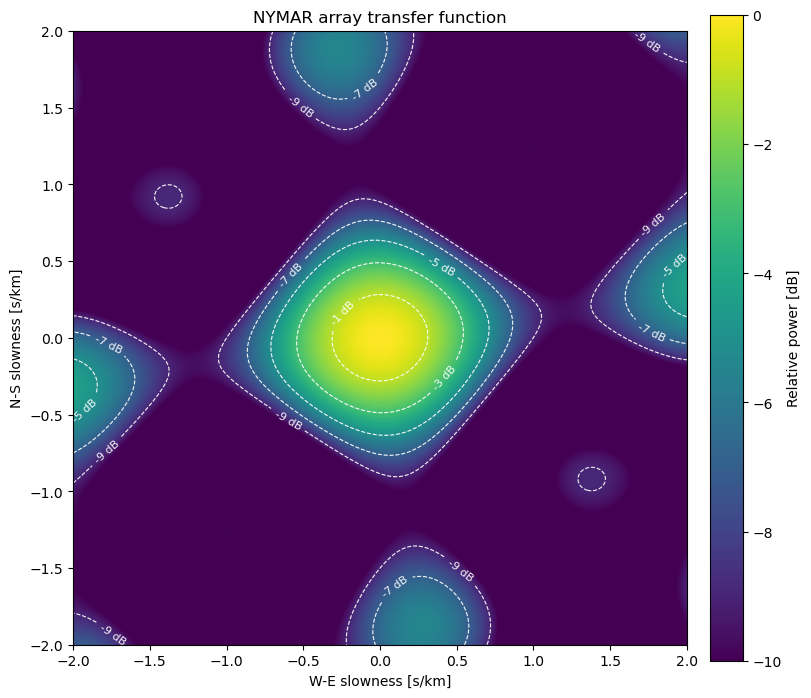

In [10]:
plot_transfer_function(
    geom,
    show_stations = False,
    sx_lim=2,
    ngrid=401,
    cmap = "viridis",
    title="NYMAR array transfer function",
    outpath="array_transfer_function_nymar.png",
)
plt.show()


## ARCES TEST

Station x/y coordinates in km:
  ARA0      x=  0.0000  y=  0.0000
  ARA1      x=  0.0530  y=  0.1600
  ARA2      x=  0.0770  y= -0.1210
  ARA3      x= -0.1490  y= -0.0300
  ARB1      x=  0.0820  y=  0.3360
  ARB2      x=  0.2940  y=  0.0970
  ARB3      x=  0.1890  y= -0.2690
  ARB4      x= -0.2310  y= -0.2250
  ARB5      x= -0.2830  y=  0.1580
  ARC1      x=  0.0810  y=  0.6900
  ARC2      x=  0.6640  y=  0.3870
  ARC3      x=  0.6730  y= -0.2140
  ARC4      x=  0.2290  y= -0.6160
  ARC5      x= -0.2960  y= -0.5380
  ARC6      x= -0.6830  y= -0.0810
  ARC7      x= -0.4710  y=  0.5300
  ARD1      x=  0.1350  y=  1.4910
  ARD2      x=  0.9720  y=  1.1430
  ARD3      x=  1.6510  y=  0.1880
  ARD4      x=  1.1810  y= -0.8580
  ARD5      x=  0.2330  y= -1.4940
  ARD6      x= -0.6130  y= -1.3470
  ARD7      x= -1.3600  y= -0.6070
  ARD8      x= -1.4430  y=  0.3920
  ARD9      x= -0.7780  y=  1.1730


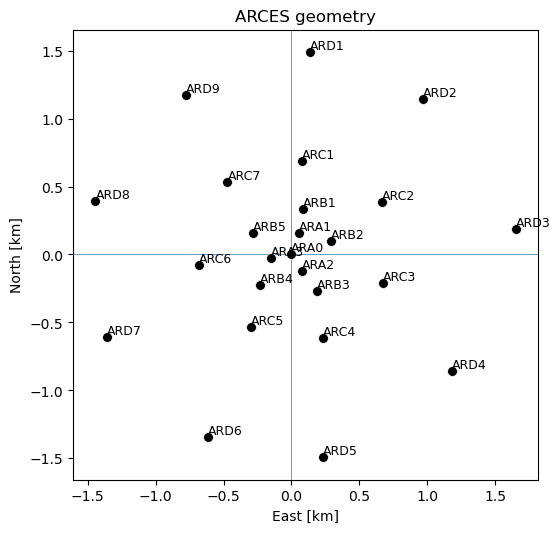

In [11]:
arces_names = [
    "ARA0", "ARA1", "ARA2", "ARA3",
    "ARB1", "ARB2", "ARB3", "ARB4", "ARB5",
    "ARC1", "ARC2", "ARC3", "ARC4", "ARC5", "ARC6", "ARC7",
    "ARD1", "ARD2", "ARD3", "ARD4", "ARD5", "ARD6", "ARD7", "ARD8", "ARD9",
]

# Relative coordinates from Fig. 9.3, in meters, relative to ARA0
arces_xy = np.array([
    [   0,    0],
    [  53,  160],
    [  77, -121],
    [-149,  -30],
    [  82,  336],
    [ 294,   97],
    [ 189, -269],
    [-231, -225],
    [-283,  158],
    [  81,  690],
    [ 664,  387],
    [ 673, -214],
    [ 229, -616],
    [-296, -538],
    [-683,  -81],
    [-471,  530],
    [ 135, 1491],
    [ 972, 1143],
    [1651,  188],
    [1181, -858],
    [ 233, -1494],
    [-613, -1347],
    [-1360, -607],
    [-1443,  392],
    [ -778, 1173],
], dtype=float)

geom = ArrayGeometry.from_xy(arces_xy/1000, labels=arces_names) # convert to km
print("Station x/y coordinates in km:")
for name, x, y in zip(geom.labels or [], geom.x_km, geom.y_km):
    print(f"  {name:8s}  x={x:8.4f}  y={y:8.4f}")

plot_array_geometry(geom, title="ARCES geometry")

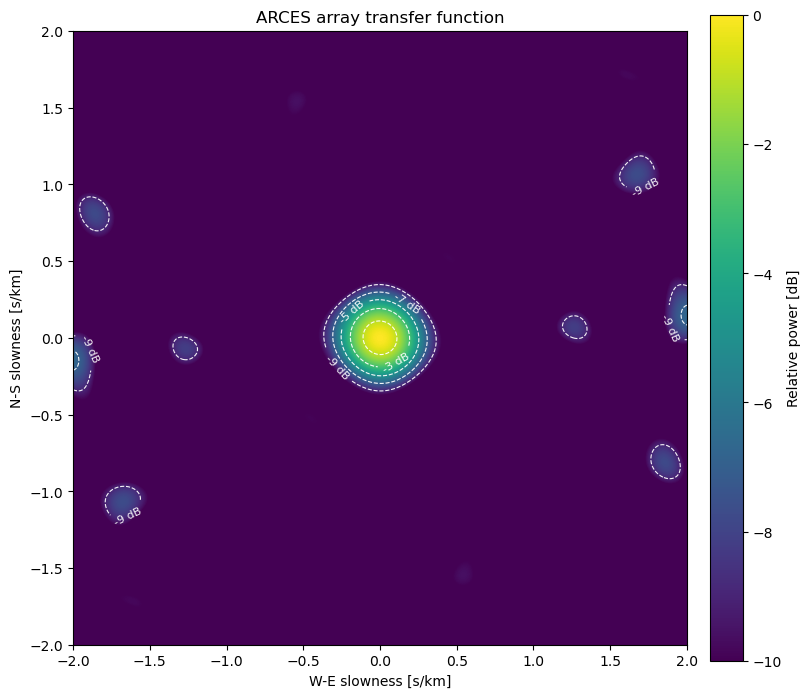

In [12]:
plot_transfer_function(
    geom,
    show_stations = False,
    sx_lim=2,
    ngrid=401,
    cmap="viridis",
    title="ARCES array transfer function",
    outpath="array_transfer_function_arces.png",
)
plt.show()

In [9]:
def generate_two_ring_array(r1, r2):
    xy = []

    # Center
    xy.append((0.0, 0.0))

    # Ring A (3 stations)
    for i in range(3):
        theta = 2 * np.pi * i / 3 + np.pi / 2
        x = r1 * np.cos(theta)
        y = r1 * np.sin(theta)
        xy.append((x, y))

    # Ring B (5 stations)
    for i in range(5):
        theta = 2 * np.pi * i / 5
        x = r2 * np.cos(theta)
        y = r2 * np.sin(theta)
        xy.append((x, y))

    return np.array(xy)

## HYPOTHETICAL ARRAY

Station x/y coordinates in km:
  C         x=  0.0000  y=  0.0000
  A1        x=  0.0000  y=  0.2300
  A2        x= -0.1992  y= -0.1150
  A3        x=  0.1992  y= -0.1150
  B1        x=  0.4945  y=  0.0000
  B2        x=  0.1528  y=  0.4703
  B3        x= -0.4001  y=  0.2907
  B4        x= -0.4001  y= -0.2907
  B5        x=  0.1528  y= -0.4703


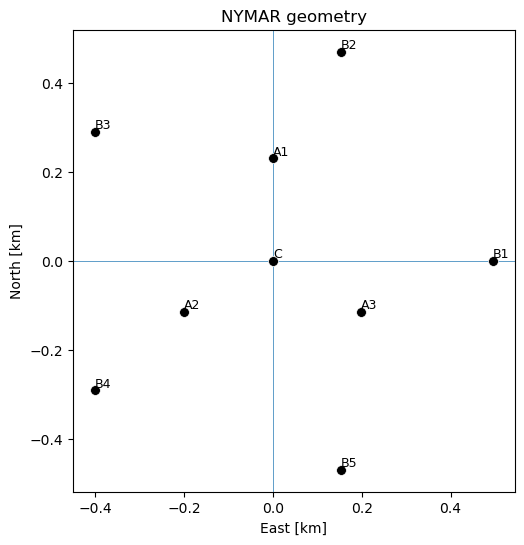

In [14]:
r1 = 0.23   # km (first ring)
alpha = 2.15 # from Schweitzer's Eq 9.28
r2 = alpha * r1
xy = generate_two_ring_array(r1, r2)
labels = ["C"] + [f"A{i+1}" for i in range(3)] + [f"B{i+1}" for i in range(5)]
geom = ArrayGeometry.from_xy(xy,labels=labels)
print("Station x/y coordinates in km:")
for name, x, y in zip(geom.labels or [], geom.x_km, geom.y_km):
    print(f"  {name:8s}  x={x:8.4f}  y={y:8.4f}")

plot_array_geometry(geom, title="NYMAR geometry")

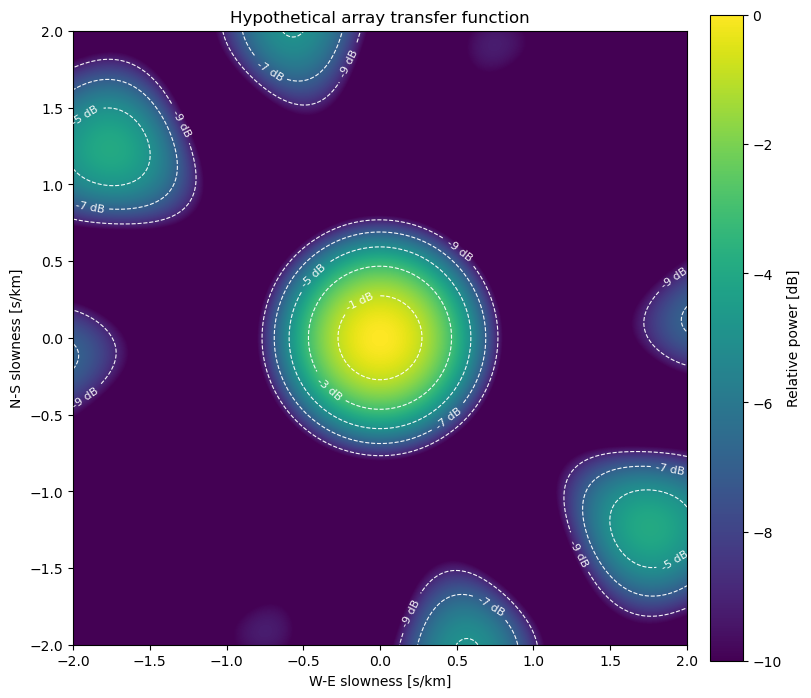

In [15]:
plot_transfer_function(
    geom,
    show_stations = False,
    sx_lim = 2,
    ngrid = 401,
    cmap = "viridis",
    title = "Hypothetical array transfer function",
    outpath = "array_transfer_function_hypo.png",
)
plt.show()

## HNAR

In [10]:
def read_kmz_points(kmz_path):
    """
    Read point placemarks from a KMZ file and return a DataFrame with
    columns: name, lon, lat, alt.

    Notes:
    - KMZ is just a zipped KML file.
    - KML coordinates are ordered lon,lat,alt.
    """
    kmz_path = Path(kmz_path)

    with zipfile.ZipFile(kmz_path, "r") as zf:
        kml_names = [n for n in zf.namelist() if n.lower().endswith(".kml")]
        if not kml_names:
            raise ValueError("No .kml file found inside the KMZ.")
        kml_text = zf.read(kml_names[0])

    ns = {"kml": "http://www.opengis.net/kml/2.2"}
    root = ET.fromstring(kml_text)

    rows = []
    for pm in root.findall(".//kml:Placemark", ns):
        name_el = pm.find("kml:name", ns)
        coord_el = pm.find(".//kml:Point/kml:coordinates", ns)

        if coord_el is None:
            continue  # skip non-point placemarks

        name = name_el.text.strip() if name_el is not None and name_el.text else "station"
        coord_text = coord_el.text.strip()
        lon, lat, *rest = coord_text.split(",")
        alt = float(rest[0]) if rest else np.nan

        rows.append(
            {
                "name": name,
                "lon": float(lon),
                "lat": float(lat),
                "alt": alt,
            }
        )

    if not rows:
        raise ValueError("No point placemarks found in the KMZ.")

    return pd.DataFrame(rows)

In [11]:
def geometry_from_kmz(kmz_path, lat0=None, lon0=None):
    df = read_kmz_points(kmz_path)
    x_km, y_km, lat0_used, lon0_used = latlon_to_local_xy_km(
        df["lat"].to_numpy(),
        df["lon"].to_numpy(),
        lat0=lat0,
        lon0=lon0,
    )
    geom = ArrayGeometry.from_xy(zip(x_km, y_km), labels=df["name"].tolist())
    return geom, df, {"lat0": lat0_used, "lon0": lon0_used}

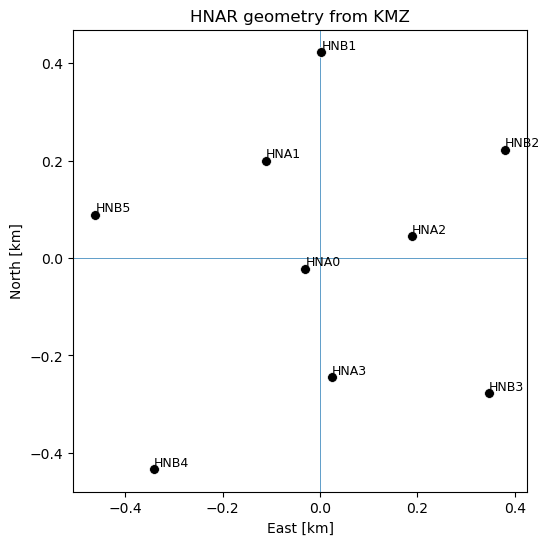

In [18]:
geom, df_kmz, meta = geometry_from_kmz("HNAR stations.kmz")

plot_array_geometry(geom, title="HNAR geometry from KMZ")

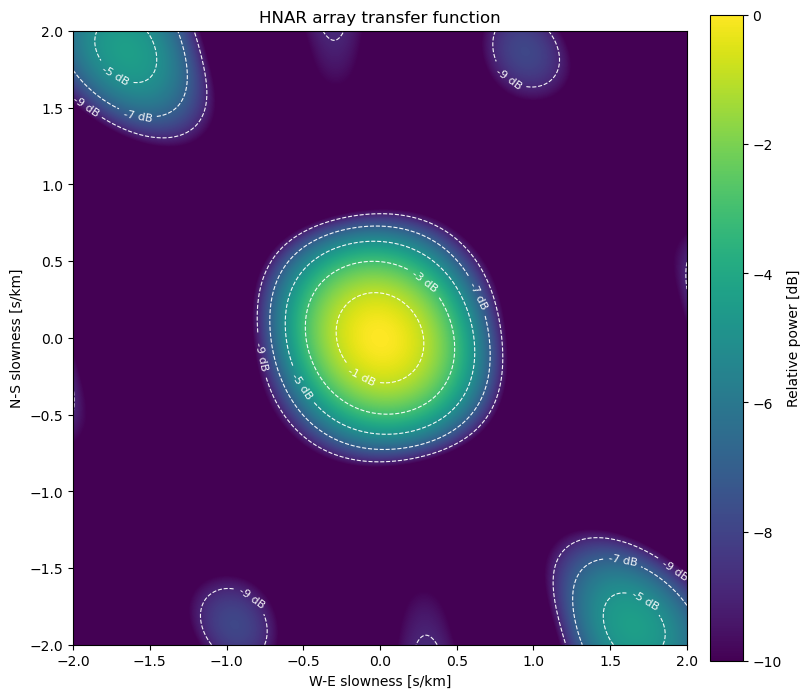

In [19]:
plot_transfer_function(
    geom,
    show_stations = False,
    sx_lim = 2,
    ngrid = 401,
    cmap = "viridis",
    title = "HNAR array transfer function",
    outpath = "array_transfer_function_hnar.png",
)
plt.show()

## Combined figure

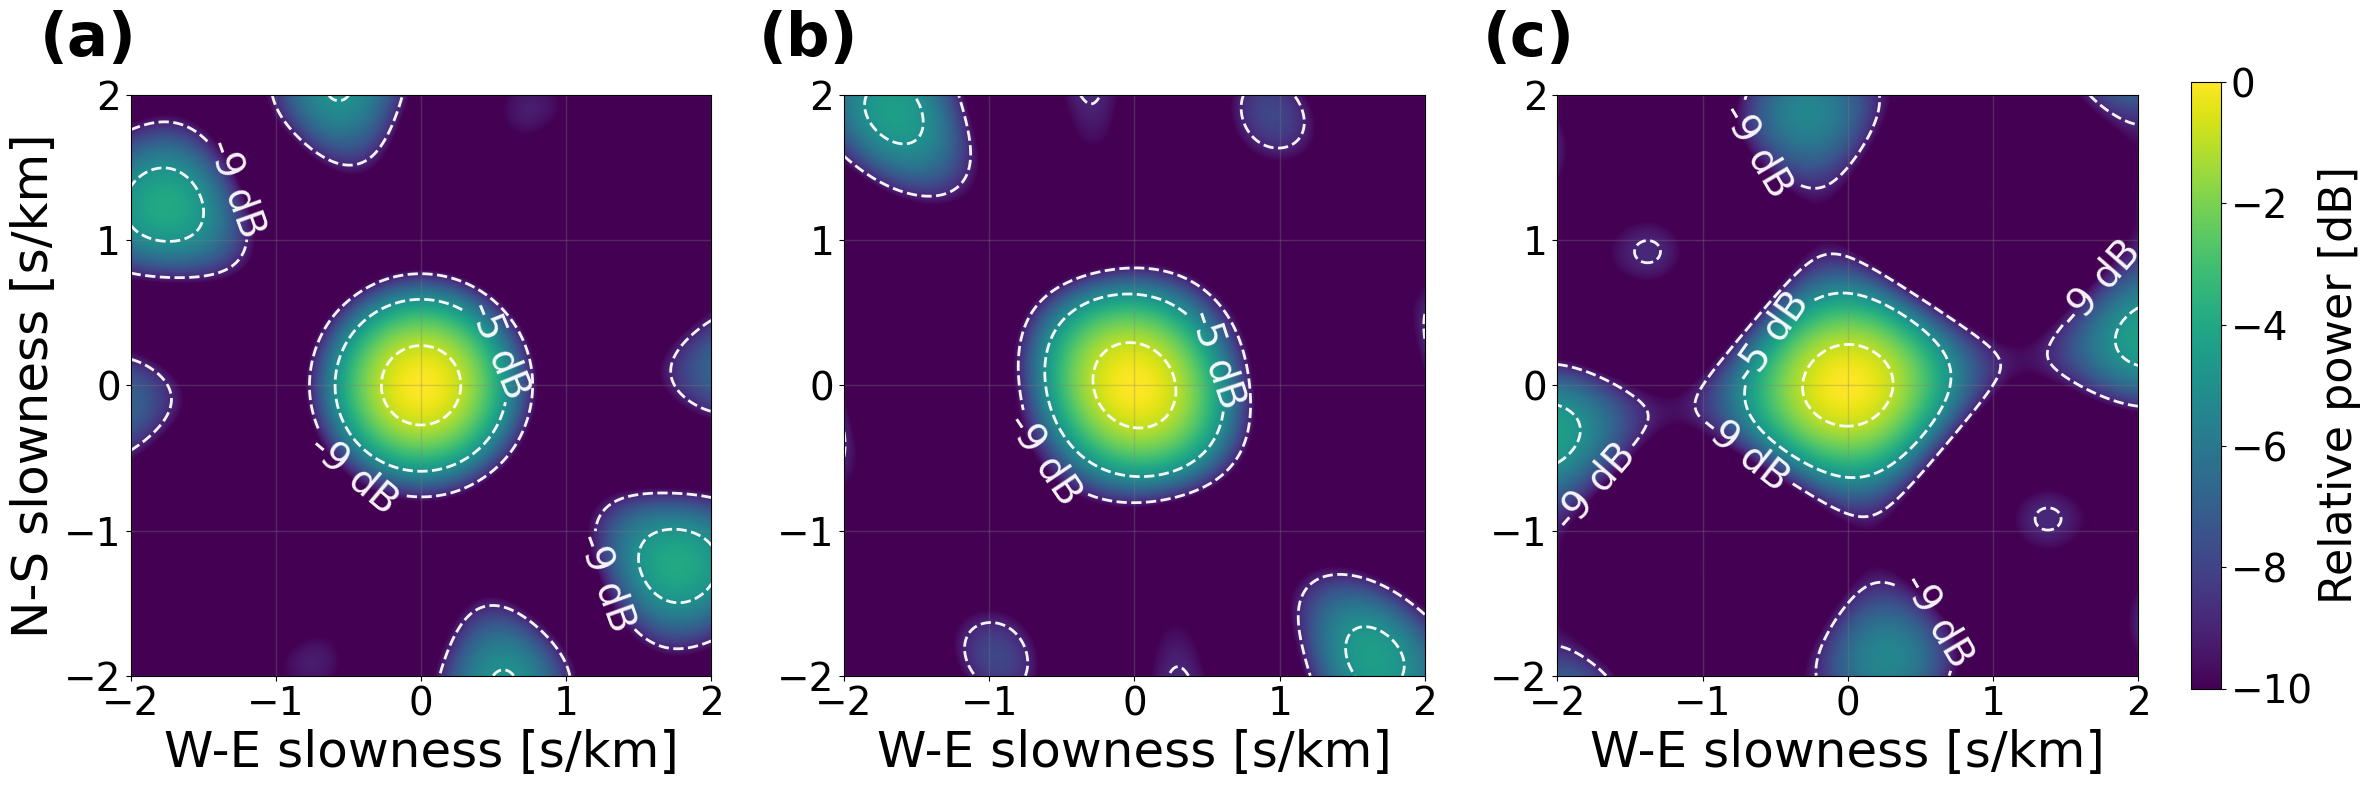

In [30]:
# Rebuild geometries and create combined figure
r1 = 0.23
alpha = 2.15
r2 = alpha * r1
xy_hypo = generate_two_ring_array(r1, r2)
labels_hypo = ["C"] + [f"A{i+1}" for i in range(3)] + [f"B{i+1}" for i in range(5)]
geom_hypo = ArrayGeometry.from_xy(xy_hypo, labels=labels_hypo)

geom_hnar, _, _ = geometry_from_kmz("HNAR stations.kmz")

geom_nymar, _ = geometry_from_latlon_csv("nymar_locs.csv")

# Create combined figure with 3 panels
fig, axes = plt.subplots(1, 3, figsize=(24, 8), constrained_layout=True)

sx_lim = 2
ngrid = 401
sx = np.linspace(-sx_lim, sx_lim, ngrid)
sy = np.linspace(-sx_lim, sx_lim, ngrid)

extent = [sx.min(), sx.max(), sy.min(), sy.max()]
levels_db = (-9, -5, -1)

geometries = [geom_hypo, geom_hnar, geom_nymar]
labels = ["(a)", "(b)", "(c)"]

for idx, (ax, geom, label) in enumerate(zip(axes, geometries, labels)):
    power_db = array_transfer_function(geom, sx, sy)
    
    im = ax.imshow(
        power_db,
        origin="lower",
        extent=extent,
        cmap="viridis",
        vmin=-10,
        vmax=0,
        aspect="equal",
        interpolation="bilinear",
    )
    
    cs = ax.contour(
        sx,
        sy,
        power_db,
        levels=sorted(levels_db),
        colors="white",
        linewidths=2.0,
        alpha=0.95,
    )
    ax.clabel(cs, fmt=lambda v: f"{v:g} dB", inline=True, fontsize=28)
    
    # X-axis label on all panels
    ax.set_xlabel("W-E slowness [s/km]", fontsize=36)
    ax.tick_params(axis='both', labelsize=28)
    
    # Y-axis label only on leftmost panel
    if idx == 0:
        ax.set_ylabel("N-S slowness [s/km]", fontsize=36)
    
    ax.grid(True, linewidth=1.0, alpha=0.3, color='gray')

# Add panel labels above the plots
fig.text(0.05, 0.99, "(a)", fontsize=44, fontweight="bold", ha="center", va="top", color="black")
fig.text(0.35, 0.99, "(b)", fontsize=44, fontweight="bold", ha="center", va="top", color="black")
fig.text(0.65, 0.99, "(c)", fontsize=44, fontweight="bold", ha="center", va="top", color="black")

# Single shared colorbar
cbar = fig.colorbar(im, ax=axes, pad=0.02, shrink=0.8)
cbar.set_label("Relative power [dB]", fontsize=32)
cbar.ax.tick_params(labelsize=28)

fig.savefig("array_transfer_function_combined.png", dpi=200, bbox_inches="tight")
plt.show()